In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 0. GPU SETUP — MUST RUN FIRST
# ══════════════════════════════════════════════════════════════════════════════
import os, time
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

import tensorflow as tf

# T4 has 16 GB — allow memory growth
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print(f"✓ GPU: {gpus[0].name}  |  Memory growth enabled")
else:
    raise RuntimeError("No GPU detected! Go to Runtime → Change runtime type → T4 GPU")

# Mixed precision — T4 has Tensor Cores that accelerate FP16
tf.keras.mixed_precision.set_global_policy('mixed_float16')
print(f"✓ Mixed precision: {tf.keras.mixed_precision.global_policy().name}")
print(f"✓ TF version: {tf.__version__}")

CLOCK_START = time.time()

✓ GPU: /physical_device:GPU:0  |  Memory growth enabled
✓ Mixed precision: mixed_float16
✓ TF version: 2.19.0


In [ ]:
import numpy as np
import pandas as pd
import json
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.utils.class_weight import compute_class_weight

from tensorflow.keras.models import Sequential
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import (
    ReduceLROnPlateau, EarlyStopping, ModelCheckpoint, TensorBoard
)
from tensorflow.keras.applications import EfficientNetB3
from tensorflow.keras.applications.efficientnet import preprocess_input

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 1. MOUNT DRIVE & EXTRACT DATA
# ══════════════════════════════════════════════════════════════════════════════
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
%%bash
# Extract data to Colab's local SSD (MUCH faster I/O than Drive)
# Using pigz for parallel decompression
tar --use-compress-program=pigz \
    -xf /content/drive/MyDrive/masterData.tar.gz \
    -C / \
    2>&1 | tail -5

echo "Exit code: $?"
echo "Dataset extracted to local SSD ✓"

Exit code: 0
Dataset extracted to local SSD ✓


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 2. CONFIGURATION — all tunables in one place
# ══════════════════════════════════════════════════════════════════════════════

DATA_DIR = '/content/masterData'                # local SSD (fast I/O)
SAVE_DIR = '/content/drive/MyDrive/crop_models' # Drive (persists after disconnect)
os.makedirs(SAVE_DIR, exist_ok=True)

# ── T4-optimized hyperparameters ─────────────────────────────────────────────
IMG_SIZE        = (300, 300)    # B3 native resolution — best accuracy
BATCH_SIZE      = 32           # T4 handles this at 300×300 with FP16
PHASE1_EPOCHS   = 10           # frozen backbone — converges fast
PHASE2_EPOCHS   = 6           # fine-tune — where the accuracy gain happens
PHASE1_LR       = 1e-3         # higher LR for frozen backbone (only head trains)
PHASE2_LR       = 2e-6         # low LR for fine-tuning backbone
UNFREEZE_TOP    = 100           # unfreeze more layers for better fine-tuning

print(f"Image: {IMG_SIZE} | Batch: {BATCH_SIZE} | FP16: ON")
print(f"Phase 1: {PHASE1_EPOCHS} epochs @ LR={PHASE1_LR}")
print(f"Phase 2: {PHASE2_EPOCHS} epochs @ LR={PHASE2_LR}")
print(f"Save to: {SAVE_DIR}")

Image: (300, 300) | Batch: 32 | FP16: ON
Phase 1: 10 epochs @ LR=0.001
Phase 2: 6 epochs @ LR=2e-06
Save to: /content/drive/MyDrive/crop_models


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 3. DATA PREPARATION — scan files + clean out corrupt entries
# ══════════════════════════════════════════════════════════════════════════════

VALID_EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp', '.gif'}

def define_paths(data_dir):
    """Walk the dataset directory and collect valid image paths."""
    filepaths, labels = [], []
    skipped = 0
    for fold in sorted(os.listdir(data_dir)):
        foldpath = os.path.join(data_dir, fold)
        if not os.path.isdir(foldpath):
            continue
        for file in os.listdir(foldpath):
            ext = os.path.splitext(file)[1].lower()
            if ext not in VALID_EXTENSIONS:
                skipped += 1
                continue
            filepath = os.path.join(foldpath, file)
            # Skip tiny files (likely corrupt)
            if os.path.getsize(filepath) < 1000:  # < 1KB
                skipped += 1
                continue
            filepaths.append(filepath)
            labels.append(fold)
    if skipped:
        print(f"⚠ Skipped {skipped} non-image/corrupt files")
    return filepaths, labels


def split_data(data_dir):
    files, classes = define_paths(data_dir)
    df = pd.concat([
        pd.Series(files, name='filepaths'),
        pd.Series(classes, name='labels')
    ], axis=1)

    train_df, temp_df = train_test_split(
        df, train_size=0.8, stratify=df['labels'], random_state=123
    )
    valid_df, test_df = train_test_split(
        temp_df, train_size=0.5, stratify=temp_df['labels'], random_state=123
    )

    print(f"Train: {len(train_df):,}  |  Valid: {len(valid_df):,}  |  Test: {len(test_df):,}")
    print(f"Classes: {df['labels'].nunique()}")
    return train_df, valid_df, test_df

train_df, valid_df, test_df = split_data(DATA_DIR)

⚠ Skipped 16 non-image/corrupt files
Train: 132,798  |  Valid: 16,600  |  Test: 16,600
Classes: 136


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 4. tf.data PIPELINE — robust image loading with error handling
# ══════════════════════════════════════════════════════════════════════════════

# Build label encoding
all_labels = sorted(train_df['labels'].unique())
label_to_idx = {lbl: i for i, lbl in enumerate(all_labels)}
idx_to_label = {i: lbl for lbl, i in label_to_idx.items()}
NUM_CLASSES = len(all_labels)
print(f"Classes: {NUM_CLASSES}")


def parse_image_train(filepath, label_idx):
    """Load + augment for training. Uses tf.image ops only (GPU-friendly)."""
    img = tf.io.read_file(filepath)
    # Use decode_jpeg with try_recover_truncated for robustness
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)

    # Augmentation
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_brightness(img, max_delta=0.15)
    img = tf.image.random_contrast(img, lower=0.85, upper=1.15)
    img = tf.image.random_saturation(img, lower=0.85, upper=1.15)

    # Random crop for scale jitter
    padded = tf.image.resize_with_crop_or_pad(
        img, int(IMG_SIZE[0] * 1.1), int(IMG_SIZE[1] * 1.1)
    )
    img = tf.image.random_crop(padded, [IMG_SIZE[0], IMG_SIZE[1], 3])

    # EfficientNet preprocess (scales to [-1, 1])
    img = preprocess_input(img)
    label = tf.one_hot(label_idx, NUM_CLASSES)
    return img, label


def parse_image_eval(filepath, label_idx):
    """Load only — no augmentation."""
    img = tf.io.read_file(filepath)
    img = tf.image.decode_jpeg(img, channels=3, try_recover_truncated=True)
    img = tf.cast(img, tf.float32)
    img = tf.image.resize(img, IMG_SIZE)
    img = preprocess_input(img)
    label = tf.one_hot(label_idx, NUM_CLASSES)
    return img, label


def build_dataset(df, batch_size, training=False):
    """Build a high-performance tf.data pipeline."""
    filepaths = df['filepaths'].values
    label_indices = np.array(
        [label_to_idx[l] for l in df['labels'].values], dtype=np.int32
    )

    ds = tf.data.Dataset.from_tensor_slices((filepaths, label_indices))

    if training:
        ds = ds.shuffle(buffer_size=min(len(df), 20000), reshuffle_each_iteration=True)
        ds = ds.map(parse_image_train, num_parallel_calls=tf.data.AUTOTUNE)
    else:
        ds = ds.map(parse_image_eval, num_parallel_calls=tf.data.AUTOTUNE)

    # Ignore errors from corrupt images instead of crashing
    ds = ds.apply(tf.data.experimental.ignore_errors())

    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(tf.data.AUTOTUNE)

    return ds


train_ds = build_dataset(train_df, BATCH_SIZE, training=True)
valid_ds = build_dataset(valid_df, BATCH_SIZE, training=False)
test_ds  = build_dataset(test_df,  BATCH_SIZE, training=False)

# Quick sanity check — grab one batch
for imgs, lbls in train_ds.take(1):
    print(f"✓ Batch shape: images={imgs.shape}, labels={lbls.shape}")
    print(f"  Pixel range: [{imgs.numpy().min():.2f}, {imgs.numpy().max():.2f}]")

print(f"\n✓ Pipelines ready  |  Elapsed: {(time.time()-CLOCK_START)/60:.1f} min")

Classes: 136


Instructions for updating:
Use `tf.data.Dataset.ignore_errors` instead.


✓ Batch shape: images=(32, 300, 300, 3), labels=(32, 136)
  Pixel range: [-14.44, 272.47]

✓ Pipelines ready  |  Elapsed: 13.3 min


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 5. CLASS WEIGHTS
# ══════════════════════════════════════════════════════════════════════════════

string_labels  = train_df['labels'].values
unique_classes = np.unique(string_labels)

weights = compute_class_weight('balanced', classes=unique_classes, y=string_labels)

# Cap extreme weights to prevent instability (max 5×)
weights = np.clip(weights, 0.5, 5.0)

string_to_weight  = dict(zip(unique_classes, weights))
class_weight_dict = {label_to_idx[cls]: w for cls, w in string_to_weight.items()}

print(f"Class weights: {len(class_weight_dict)} (capped at 5.0)")
top5 = sorted(class_weight_dict.items(), key=lambda x: x[1], reverse=True)[:5]
print("Top-5 minority classes:")
for idx, w in top5:
    print(f"  {idx_to_label[idx]:45s}  weight={w:.3f}")

Class weights: 136 (capped at 5.0)
Top-5 minority classes:
  cardamom_blight1000                            weight=5.000
  coconut_healthy_leaves                         weight=5.000
  coffee_red_spider_mite                         weight=5.000
  groundnut_rust                                 weight=5.000
  potato___healthy                               weight=5.000


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 6. FOCAL LOSS
# ══════════════════════════════════════════════════════════════════════════════

from tensorflow.keras.utils import register_keras_serializable

@register_keras_serializable()
def focal_loss(y_true, y_pred, gamma=2.0, alpha=0.25):
    """
    Focal loss — down-weights easy examples, focuses on hard/minority classes.
    Registered for serialization so model.save() / load_model() works.
    """
    y_pred = tf.clip_by_value(y_pred, 1e-7, 1.0)
    ce     = -y_true * tf.math.log(y_pred)
    pt     = tf.reduce_sum(y_true * y_pred, axis=-1, keepdims=True)
    loss   = alpha * tf.pow(1.0 - pt, gamma) * ce
    return tf.reduce_mean(tf.reduce_sum(loss, axis=-1))

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 7. BUILD MODEL
# ══════════════════════════════════════════════════════════════════════════════

img_shape = (*IMG_SIZE, 3)  # (300, 300, 3)

base_model = EfficientNetB3(
    include_top=False,
    weights='imagenet',
    input_shape=img_shape,
    pooling='avg'
)
base_model.trainable = False  # frozen for Phase 1

model = Sequential([
    base_model,
    BatchNormalization(),
    Dense(512, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    Dropout(0.4),
    Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.0005)),
    Dropout(0.3),
    # float32 softmax for numerical stability with mixed precision
    Dense(NUM_CLASSES, activation='softmax', dtype='float32')
])

model.compile(
    optimizer=Adam(learning_rate=PHASE1_LR),
    loss=focal_loss,
    metrics=['accuracy']
)

model.summary()

trainable = sum(1 for l in model.trainable_weights)
total = model.count_params()
print(f"\n✓ Total params: {total:,}")

43941136/43941136 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb3 (Functional)     │ (None, 1536)           │    10,783,535 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1536)           │         6,144 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       786,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 136)            │        34,952 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,742,903 (44.80 MB)

 Trainable params: 956,296 (3.65 MB)

 Non-trainable params: 10,786,607 (41.15 MB)


✓ Total params: 11,742,903


In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# RESUME PHASE 2 — Continue Fine-tuning EfficientNetB3
# ══════════════════════════════════════════════════════════════════════════════

from tensorflow.keras.models import load_model
from tensorflow.keras.optimizers import Adam
import tensorflow as tf
import os, json, time

# Load Phase 2 BEST model (not Phase 1)
model = load_model("/content/drive/MyDrive/crop136_b3_phase2_best.keras")
print("Phase 2 best model loaded ✓")

# Locate EfficientNet base
base_model = next(
    layer for layer in model.layers
    if 'efficientnet' in layer.name.lower()
)
print(f"Base: {base_model.name}  |  {len(base_model.layers)} layers")

# Progressive unfreezing (increase layers)
NEW_UNFREEZE_TOP = UNFREEZE_TOP + 50   # increase by 50–100

base_model.trainable = True
for layer in base_model.layers[:-NEW_UNFREEZE_TOP]:
    layer.trainable = False

# Freeze BatchNorm layers (critical)
for layer in base_model.layers:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

trainable_count = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable: {trainable_count} / {len(base_model.layers)} layers")

# Lower LR for stable fine-tuning
model.compile(
    optimizer=Adam(learning_rate=5e-6),
    loss=focal_loss,
    metrics=['accuracy']
)

# Paths
p2_best_path = os.path.join(SAVE_DIR, 'crop136_b3_phase2_best.keras')
p2_history_path = os.path.join(SAVE_DIR, 'crop136_b3_phase2_history.json')

# Callbacks
callbacks_p2 = [
    ReduceLROnPlateau(
        monitor='val_loss', factor=0.5, patience=2, min_lr=1e-8, verbose=1
    ),
    EarlyStopping(
        monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1
    ),
    ModelCheckpoint(
        p2_best_path, monitor='val_accuracy',
        save_best_only=True, verbose=1
    ),
]

print("\n" + "=" * 65)
print(f"RESUMING PHASE 2 (top {NEW_UNFREEZE_TOP} layers)")
print(f"  {IMG_SIZE} | BS={BATCH_SIZE} | LR=5e-6 | FP16 | +{PHASE2_EPOCHS} epochs")
print("=" * 65)

# Train
t2 = time.time()

history_phase2 = model.fit(
    train_ds,
    validation_data=valid_ds,
    epochs=PHASE2_EPOCHS,
    callbacks=callbacks_p2,
    class_weight=class_weight_dict,
    verbose=1
)

print(f"\n✓ Resume Phase 2 done in {(time.time()-t2)/60:.1f} min")

# Save history
with open(p2_history_path, 'w') as f:
    json.dump(history_phase2.history, f)

print(f"✓ Updated best model → {p2_best_path}")

Phase 2 best model loaded ✓
Base: efficientnetb3  |  386 layers
Trainable: 63 / 386 layers

RESUMING PHASE 2 (top 150 layers)
  (300, 300) | BS=32 | LR=5e-6 | FP16 | +6 epochs
Epoch 1/6
   4149/Unknown 1494s 329ms/step - accuracy: 0.9119 - loss: 0.1277
Epoch 1: val_accuracy improved from None to 0.95337, saving model to /content/drive/MyDrive/crop_models/crop136_b3_phase2_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/crop_models/crop136_b3_phase2_best.keras
4149/4149 ━━━━━━━━━━━━━━━━━━━━ 1719s 384ms/step - accuracy: 0.9128 - loss: 0.1259 - val_accuracy: 0.9534 - val_loss: 0.1062 - learning_rate: 5.0000e-06
Epoch 2/6
4149/4149 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - accuracy: 0.9196 - loss: 0.1193
Epoch 2: val_accuracy improved from 0.95337 to 0.95626, saving model to /content/drive/MyDrive/crop_models/crop136_b3_phase2_best.keras

Epoch 2: finished saving model to /content/drive/MyDrive/crop_models/crop136_b3_phase2_best.keras
4149/4149 ━━━━━━━━━━━━━━━━━━━━ 1506s 36

In [12]:
# ══════════════════════════════════════════════════════════════════════════════
# 11. EVALUATION
# ══════════════════════════════════════════════════════════════════════════════

# Load the best checkpoint
model = load_model(p2_best_path)
print("Best Phase 2 model loaded ✓")

valid_score = model.evaluate(valid_ds, verbose=1)
test_score  = model.evaluate(test_ds, verbose=1)

print("\n" + "=" * 65)
print(f"Validation Accuracy: {valid_score[1]:.4f}  |  Loss: {valid_score[0]:.4f}")
print(f"Test       Accuracy: {test_score[1]:.4f}  |  Loss: {test_score[0]:.4f}")
print("=" * 65)

# Check if we hit the target
if valid_score[1] >= 0.95:
    print("\n🎯 TARGET ACHIEVED: ≥ 95% validation accuracy!")
else:
    print(f"\n⚠ {valid_score[1]*100:.1f}% — below 95% target. Consider more Phase 2 epochs.")

total_time = (time.time() - CLOCK_START) / 60
print(f"\n⏱ Total training time: {total_time:.1f} min ({total_time/60:.1f} hrs)")

Best Phase 2 model loaded ✓
519/519 ━━━━━━━━━━━━━━━━━━━━ 205s 324ms/step - accuracy: 0.9635 - loss: 0.0794
519/519 ━━━━━━━━━━━━━━━━━━━━ 196s 377ms/step - accuracy: 0.9641 - loss: 0.0802

Validation Accuracy: 0.9635  |  Loss: 0.0794
Test       Accuracy: 0.9641  |  Loss: 0.0802

🎯 TARGET ACHIEVED: ≥ 95% validation accuracy!

⏱ Total training time: 175.2 min (2.9 hrs)


In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# 12. CLASSIFICATION REPORT (per-class metrics)
# ══════════════════════════════════════════════════════════════════════════════

y_pred_list, y_true_list = [], []
for images, labels in test_ds:
    preds = model.predict(images, verbose=0)
    y_pred_list.append(np.argmax(preds, axis=1))
    y_true_list.append(np.argmax(labels.numpy(), axis=1))

y_pred = np.concatenate(y_pred_list)
y_true = np.concatenate(y_true_list)

target_names = [idx_to_label[i] for i in range(NUM_CLASSES)]

print("Classification Report:")
print(classification_report(y_true, y_pred, target_names=target_names))

Classification Report:
                                             precision    recall  f1-score   support

                           apple_apple_scab       1.00      0.97      0.98        63
                            apple_black_rot       0.98      1.00      0.99        62
                     apple_cedar_apple_rust       1.00      1.00      1.00        27
                              apple_healthy       0.99      1.00      1.00       164
                             banana_cordana       1.00      0.97      0.99        34
                             banana_healthy       0.98      1.00      0.99       100
                      banana_panama_disease       1.00      0.96      0.98        84
           banana_yellow_and_black_sigatoka       0.98      0.99      0.99       250
                       black_pepper_footrot       1.00      1.00      1.00        50
                 black_pepper_pollu_disease       1.00      1.00      1.00        50
                  black_pepper_slow-decli

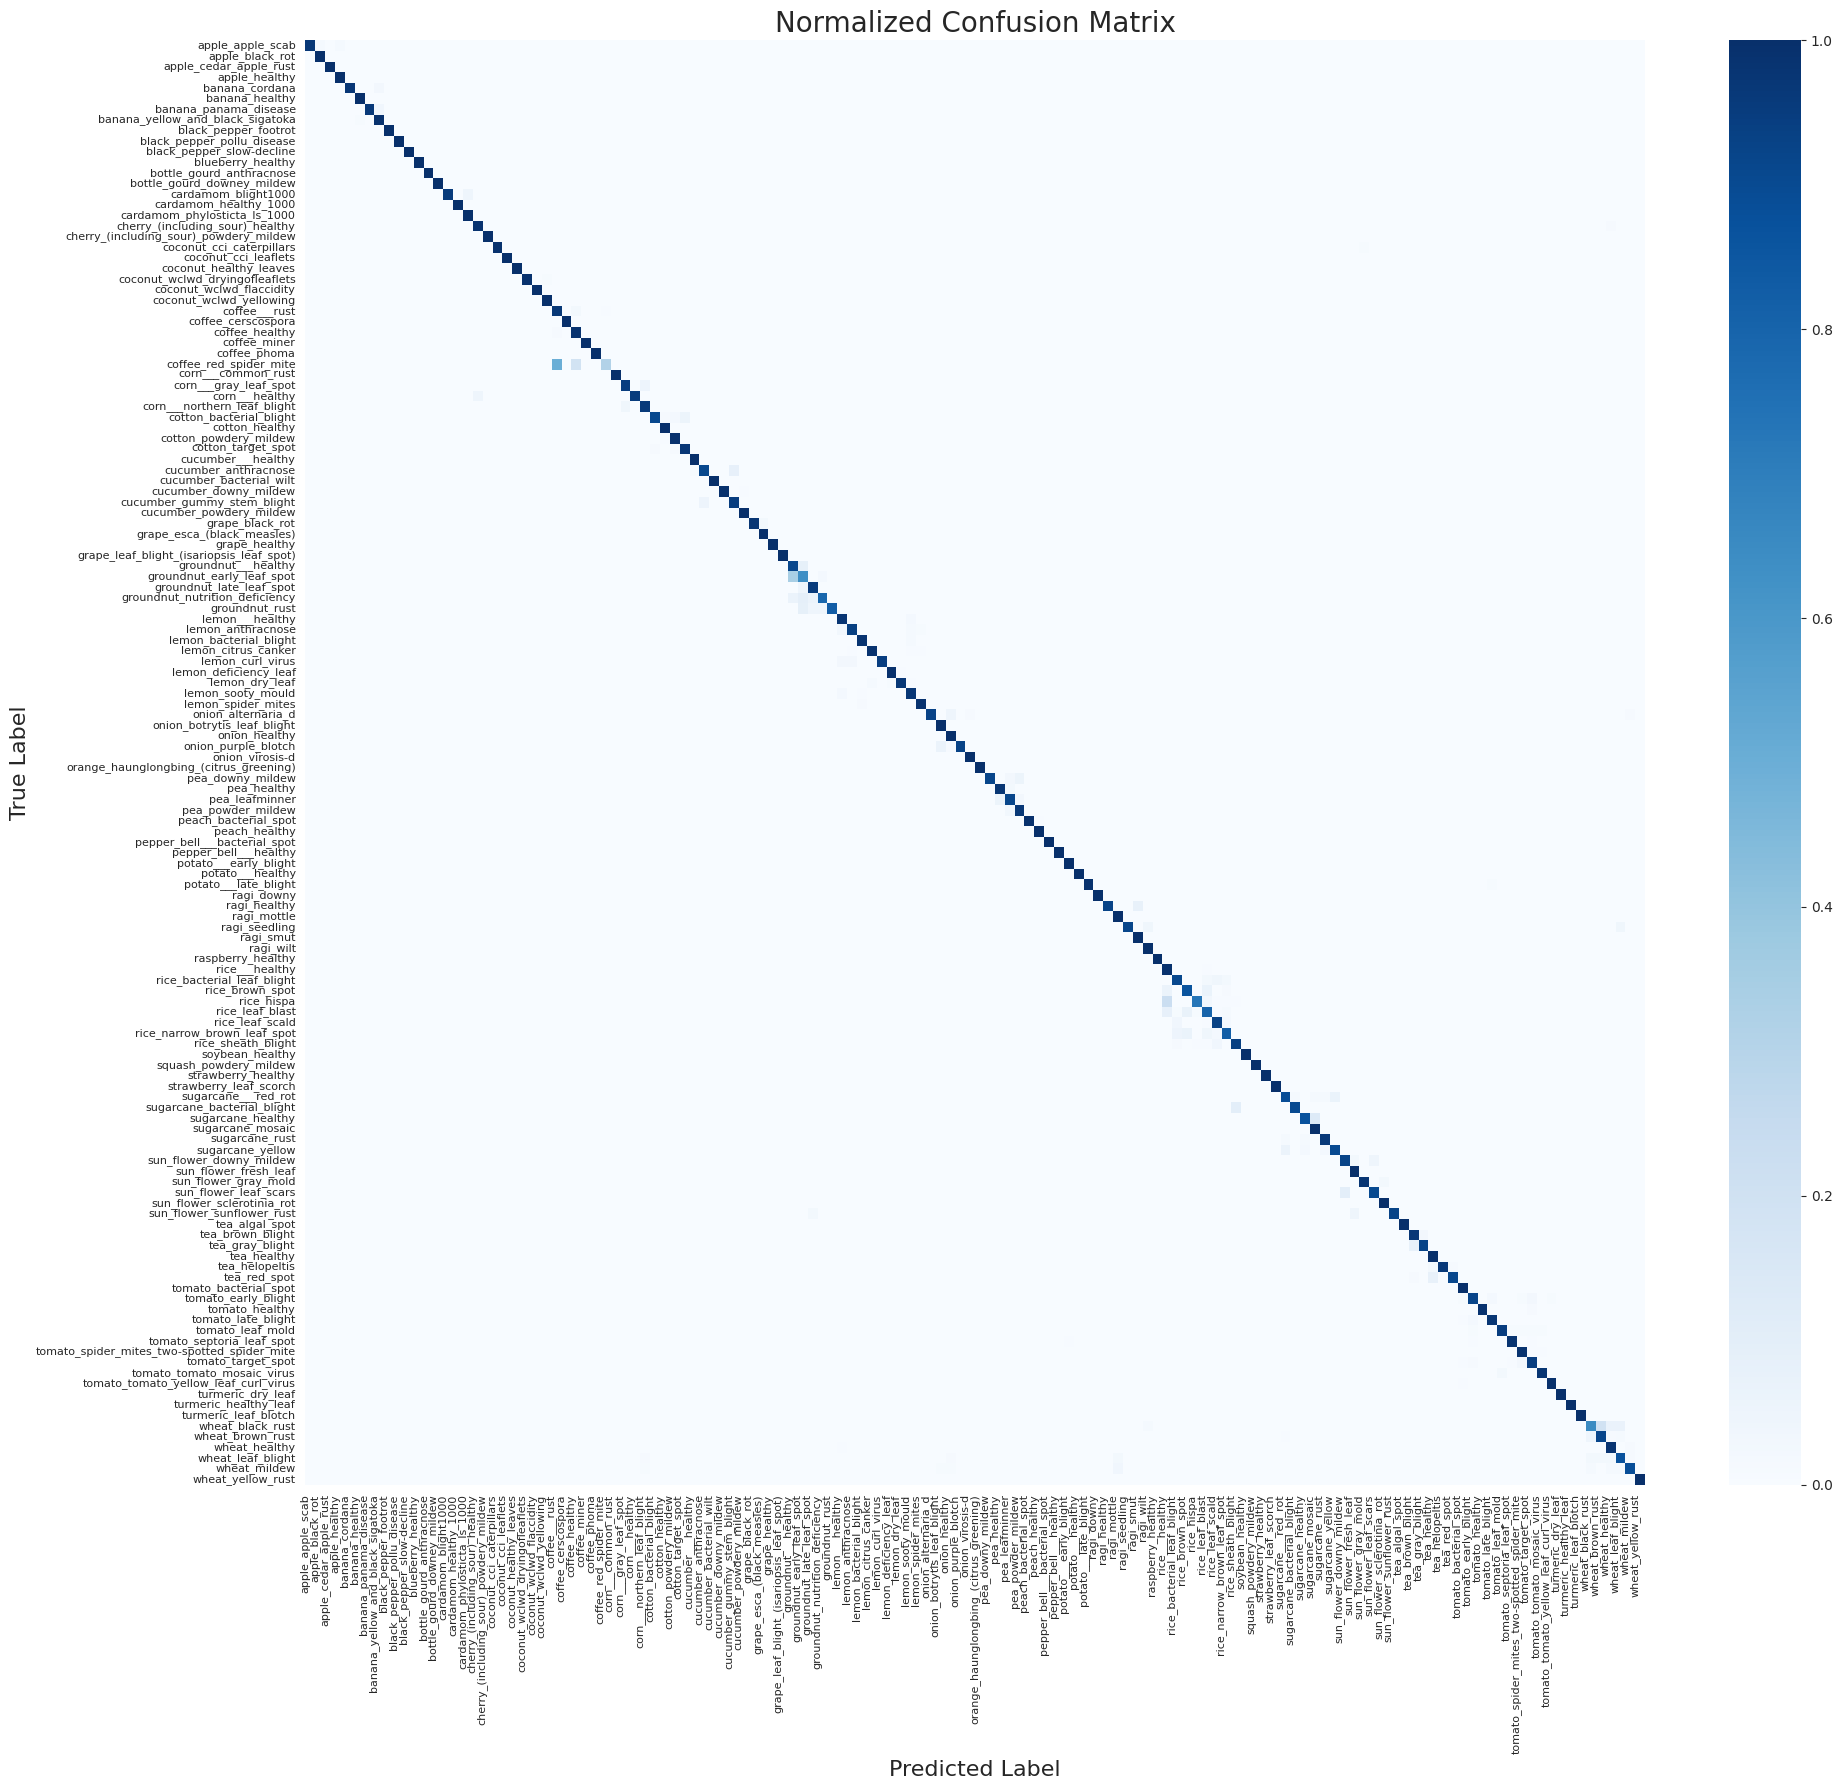

In [15]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Normalize the confusion matrix by the number of true instances per class
# This makes it easier to see classification rates rather than raw counts
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]

# Set up the plot
plt.figure(figsize=(20, 18))
sns.heatmap(
    cm_normalized,
    annot=False,  # Set to True for raw numbers, False for just colors
    cmap='Blues', # Color map
    fmt='.2f',    # Format for annotations
    xticklabels=target_names, # Use actual class names for x-axis
    yticklabels=target_names  # Use actual class names for y-axis
)

plt.title('Normalized Confusion Matrix', fontsize=20)
plt.xlabel('Predicted Label', fontsize=16)
plt.ylabel('True Label', fontsize=16)
plt.xticks(rotation=90, ha='right', fontsize=8)
plt.yticks(rotation=0, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

In [ ]:
# ══════════════════════════════════════════════════════════════════════════════
# 14. EXPORT FINAL MODEL (for deployment)
# ══════════════════════════════════════════════════════════════════════════════

final_path = os.path.join(SAVE_DIR, 'crop136_b3_final.keras')
model.save(final_path)

# Save label mapping
label_map_path = os.path.join(SAVE_DIR, 'label_map.json')
with open(label_map_path, 'w') as f:
    json.dump(idx_to_label, f, indent=2)

print(f"\n✓ Final model  → {final_path}")
print(f"✓ Label map    → {label_map_path}")
print(f"✓ Total time   → {(time.time()-CLOCK_START)/60:.1f} min")
print(f"\n📁 All files saved to Google Drive — safe from Colab disconnect.")